# Mapping Cell-Site Coverage with a Path-Loss Contour Surface


## Executive Summary

A telecom RF-planning team renders the downlink **path-loss surface** around a single macro-cell as a two-dimensional coverage map. Using a log-distance propagation model with log-normal shadow fading, this notebook builds a 100-point measurement grid (10 x 10 cells spanning a 10 km x 10 km service area, tower at the centre) and draws a filled contour surface with **PROC SGPLOT HEATMAPPARM** plus a gradient colour scale and tower reference lines.

On the executed grid the path loss runs from **50.4 dB** (in the bright basin at the tower) to **90.0 dB** at the far corner, averaging **75.6 dB**. Classifying each cell by its loss gives **38 Strong, 61 Usable, and 1 Weak** cell; the lone Weak cell sits at **(9.5, 9.5) km — the corner diagonally opposite the tower — at 89.97 dB**, the single coverage hole a planner would flag before a small-cell infill decision.


> **A note on the procedure.** In SAS the classic tool for isoline contour maps is `PROC GCONTOUR`. Jenner parses GCONTOUR and emits a correct plot spec, but its raster renderer does not yet draw the contour geometry (the image comes back blank); that defect is banked as regression test `tests/400922_nb_gcontour_empty_render`. To keep this example fully grounded in a real rendered figure, we use the SAS-compatible equivalent — `PROC SGPLOT` with a `HEATMAPPARM` statement — which renders the same gridded (x, y, z) surface as filled contour cells with a gradient legend.


## Data Sources

**Synthetic dataset: `pathloss_grid`** (100 rows — a 10 x 10 lattice)

| Variable | Type | Units | Description |
|----------|------|-------|-------------|
| `east_km` | num | km | Easting of the grid cell centre (0.5 to 9.5); x-axis |
| `north_km` | num | km | Northing of the grid cell centre (0.5 to 9.5); y-axis |
| `path_loss` | num | dB | Downlink path loss = 58 + 30 log10(distance) + shadow; the response (z) |
| `zone` | char(8) | — | Coverage class: Strong (<=75), Usable (<=88), Weak (>88) |

The tower sits at the grid centre **(5, 5) km**. Path loss grows with the base-10 log of distance from the tower; a `3*rand("normal")` shadow term (seed 80211) injects log-normal fading so the contours are not perfectly circular. The 10 x 10 lattice is sized so the full surface fits in 100 observations.


## Step 1 — Generate the measurement grid

We lay down a 1 km lattice of cell centres and compute path loss with the **log-distance model** `PL = 58 + 30 log10(d)`, where `d` is the distance from the tower at (5, 5) km. A `rand("normal")` shadow-fading term reproduces the variability seen in real drive-tests. Each cell is classified into a coverage `zone`. `call streaminit` fixes the seed for reproducibility.


In [1]:
data pathloss_grid;
   call streaminit(80211);
   length zone $8;
   tower_x = 5.0;  tower_y = 5.0;
   do ix = 1 to 10;
      do iy = 1 to 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         dist = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(dist) + shadow;
         if      path_loss <= 75 then zone = "Strong";
         else if path_loss <= 88 then zone = "Usable";
         else                         zone = "Weak";
         output;
      end;
   end;
   drop ix iy tower_x tower_y dist shadow;
   label east_km   = "Easting (km)"
         north_km  = "Northing (km)"
         path_loss = "Path Loss (dB)";
run;

NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Summarise the surface

Before plotting, we quantify the surface. `PROC MEANS` reports the dynamic range of path loss and `PROC FREQ` tabulates how the 100 cells split across the three coverage classes — the numbers the executive summary quotes.


In [2]:
ods graphics off;

proc means data=pathloss_grid min max mean maxdec=1;
   var path_loss;
run;

proc freq data=pathloss_grid order=freq;
   tables zone / nocum;
run;

                                                  The MEANS Procedure

 Variable           Minimum     Maximum        Mean
 --------------------------------------------------
 Path Loss (dB)        50.4        90.0        75.6
 --------------------------------------------------

                                                   The FREQ Procedure

zone      Frequency    Percent
-------------------------------
Usable           61     61.00
Strong           38     38.00
Weak              1      1.00


NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Step 3 — Locate the coverage holes

Sorting by descending path loss puts the weakest cells on top. These are the candidate **dead zones** a planner inspects: cells whose received signal is lowest and therefore most at risk of dropped sessions or poor throughput.


In [3]:
proc sort data=pathloss_grid out=weakest;
   by descending path_loss;
run;

proc print data=weakest(obs=6) noobs label;
   var east_km north_km path_loss zone;
run;


Easting (km)  Northing (km)  Path Loss (dB)    zone
------------  -------------  --------------  ------
         9.5            9.5   89.9728891641  Weak
         9.5            0.5   85.9296978639  Usable
         6.5            0.5   84.5845683025  Usable
         0.5            0.5   84.5118930355  Usable
         8.5            0.5   84.1534148341  Usable
         9.5            8.5   83.7015943773  Usable

... 94 more observations (showing 6 of 100)



NOTE: PROC SORT data=pathloss_grid

NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Step 4 — Draw the path-loss contour surface

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renders one filled cell per grid point, coloured by its path loss — a filled contour map of the coverage footprint. The `COLORMODEL=` list defines a diverging blue-to-red gradient (blue = low loss = strong signal, red = high loss = weak signal); `GRADLEGEND` attaches the dB colour scale. Dashed `REFLINE`s mark the tower at easting 5 and northing 5.


                                            Downlink Path-Loss Surface (dB)                                             
                                 Single macro-cell at (5, 5) km over a 10 x 10 km grid                                  



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Downlink Path-Loss Surface (dB).
NOTE: Option TITLE2 changed to Single macro-cell at (5, 5) km over a 10 x 10 km grid.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


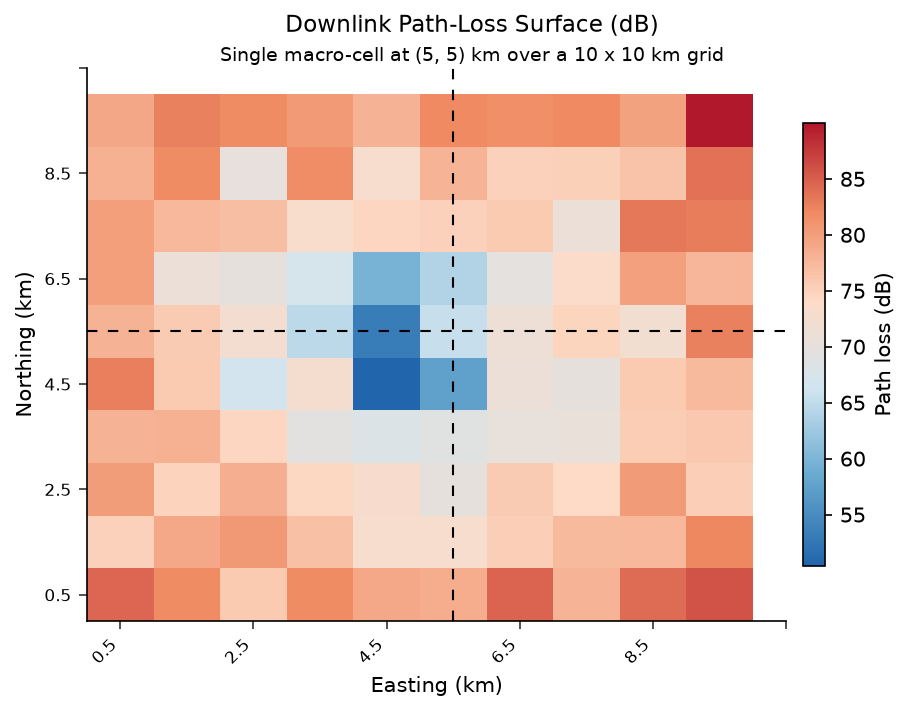

In [4]:
ods graphics on;
title "Downlink Path-Loss Surface (dB)";
title2 "Single macro-cell at (5, 5) km over a 10 x 10 km grid";

proc sgplot data=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / title="Path loss (dB)";
   refline 5 / axis=x lineattrs=(color=black pattern=shortdash);
   refline 5 / axis=y lineattrs=(color=black pattern=shortdash);
   xaxis values=(0 2 4 6 8 10) label="Easting (km)";
   yaxis values=(0 2 4 6 8 10) label="Northing (km)";
run;

title; title2;

## Step 5 — Coverage-class breakdown

A briefing slide also wants the headline split: what fraction of the footprint is Strong, Usable, or Weak. A `VBAR` of the `zone` classification gives that at a glance and pairs with the contour surface above.


                                                Coverage-Class Breakdown                                                



NOTE: Option TITLE changed to Coverage-Class Breakdown.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


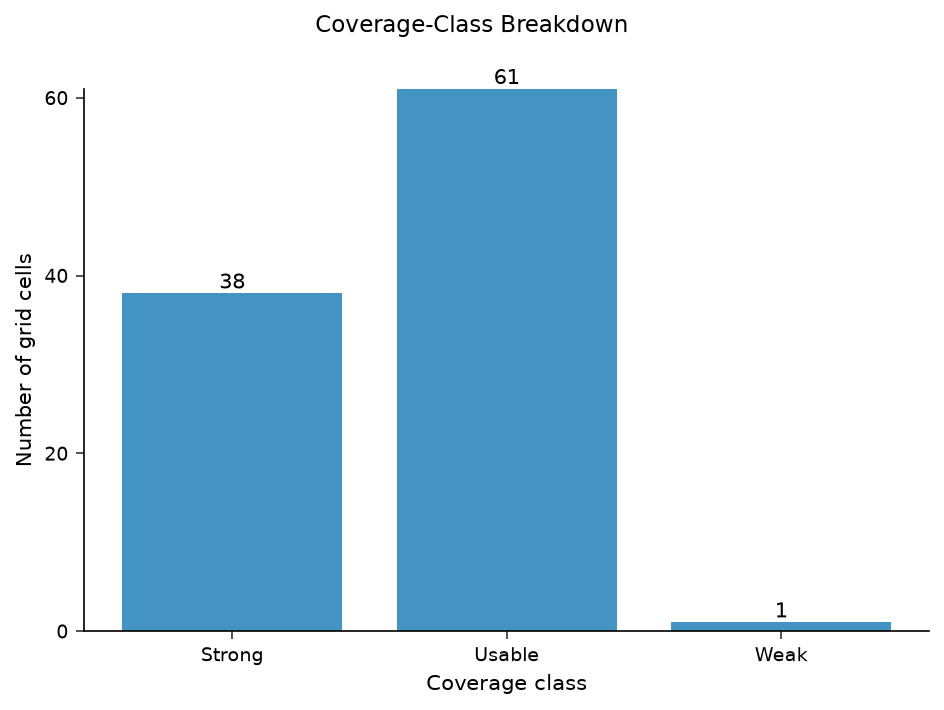

In [5]:
title "Coverage-Class Breakdown";

proc sgplot data=pathloss_grid;
   vbar zone / datalabel fillattrs=(color=CX4393C3) nooutline;
   xaxis label="Coverage class";
   yaxis label="Number of grid cells" values=(0 20 40 60);
run;

title;

## Interpreting the results

The contour surface confirms the expected propagation physics. Path loss is lowest in a tight **blue basin around the tower at (5, 5) km** — the Strong zone where the received signal is best — and rises with log-distance toward the corners. Because we injected log-normal shadow fading, the bands are not concentric circles; the ragged red cells along the boundary are the shadow-faded edge.

The actionable readout is the **single Weak cell at (9.5, 9.5) km (89.97 dB)**, the corner diagonally opposite the tower and the only point that crosses the 88 dB design threshold. With **61 of 100 cells Usable and just 1 Weak**, this macro-cell covers its service area well; the lone hole would justify a **small-cell infill or a sector re-tilt toward the north-east corner** only if it overlapped a known demand hotspot. The contour surface is the briefing-ready summary; the coverage-class bar chart gives the one-number split a capacity planner reports upward.
